# Step 1: Load Dataset and Initial Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Cardiotocographic.csv")

In [3]:
# Display first 5 rows
print("First 5 Rows of Dataset:\n")
print(df.head())

First 5 Rows of Dataset:

           LB        AC   FM        UC        DL   DS   DP  ASTV  MSTV  ALTV  \
0  120.000000  0.000000  0.0  0.000000  0.000000  0.0  0.0  73.0   0.5  43.0   
1  132.000000  0.006380  0.0  0.006380  0.003190  0.0  0.0  17.0   2.1   0.0   
2  133.000000  0.003322  0.0  0.008306  0.003322  0.0  0.0  16.0   2.1   0.0   
3  134.000000  0.002561  0.0  0.007742  0.002561  0.0  0.0  16.0   2.4   0.0   
4  131.948232  0.006515  0.0  0.008143  0.000000  0.0  0.0  16.0   2.4   0.0   

   MLTV  Width  Tendency  NSP  
0   2.4   64.0  0.999926  2.0  
1  10.4  130.0  0.000000  1.0  
2  13.4  130.0  0.000000  1.0  
3  23.0  117.0  1.000000  1.0  
4  19.9  117.0  1.000000  1.0  


In [ ]:
# Shape of dataset
print("\nShape of Dataset:")
print(df.shape)


Shape of Dataset:
(2126, 14)


In [ ]:
# Column names
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')


In [ ]:
# Dataset summary using info()
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB
None


# Step 2 — Data Cleaning + Missing Values + Data Type Corrections

In [4]:
# Check Missing Values

print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64


In [ ]:
print("\nData Types of Each Column:\n")
print(df.dtypes)


Data Types of Each Column:

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


In [ ]:
# Convert Incorrect Data Types (if needed)

df["LB"] = pd.to_numeric(df["LB"], errors="coerce")

In [5]:
# Fill missing numerical values using median

for column in df.columns:
    if df[column].dtype != "object":
        df[column] = df[column].fillna(df[column].median())

print("\nMissing Values After Treatment:\n")
print(df.isnull().sum())


Missing Values After Treatment:

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64


# Step 3 — Outlier Detection + Treatment Strategy

In [6]:
# Detect Outliers using IQR

for column in df.select_dtypes(include=[np.number]).columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} outliers")

LB: 10 outliers
AC: 43 outliers
FM: 347 outliers
UC: 13 outliers
DL: 125 outliers
DS: 120 outliers
DP: 284 outliers
ASTV: 10 outliers
MSTV: 80 outliers
ALTV: 318 outliers
MLTV: 81 outliers
Width: 10 outliers
Tendency: 10 outliers
NSP: 559 outliers


In [ ]:
# Capping Outliers

for column in df.select_dtypes(include=[np.number]).columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = np.where(
        df[column] > upper_bound,
        upper_bound,
        np.where(
            df[column] < lower_bound,
            lower_bound,
            df[column]
        )
    )

# Step 4 — Statistical Summary (Mean, Median, Standard Deviation, IQR)

In [7]:
# Statistical Summary

summary_stats = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Standard Deviation": df.std(),
    "Q1 (25%)": df.quantile(0.25),
    "Q3 (75%)": df.quantile(0.75)
})

summary_stats["IQR"] = summary_stats["Q3 (75%)"] - summary_stats["Q1 (25%)"]

print("Statistical Summary:\n")
print(summary_stats)

Statistical Summary:

                Mean      Median  Standard Deviation    Q1 (25%)    Q3 (75%)  \
LB        133.340204  133.000000           11.214379  126.000000  140.000000   
AC          0.003204    0.001634            0.004373    0.000000    0.005606   
FM          0.009894    0.000000            0.067540    0.000000    0.002567   
UC          0.004391    0.004484            0.003340    0.001851    0.006536   
DL          0.001895    0.000000            0.003343    0.000000    0.003289   
DS          0.000002    0.000000            0.000141    0.000000    0.000000   
DP          0.000173    0.000000            0.000836    0.000000    0.000000   
ASTV       46.995984   49.000000           18.813973   32.000000   61.000000   
MSTV        1.364378    1.200000            1.173632    0.700000    1.700000   
ALTV       10.285964    0.000000           21.205041    0.000000   11.000000   
MLTV        8.276147    7.400000            7.734851    4.600000   10.800000   
Width      70.3953

# Step 5 — Histograms + Boxplots for Distribution Analysis

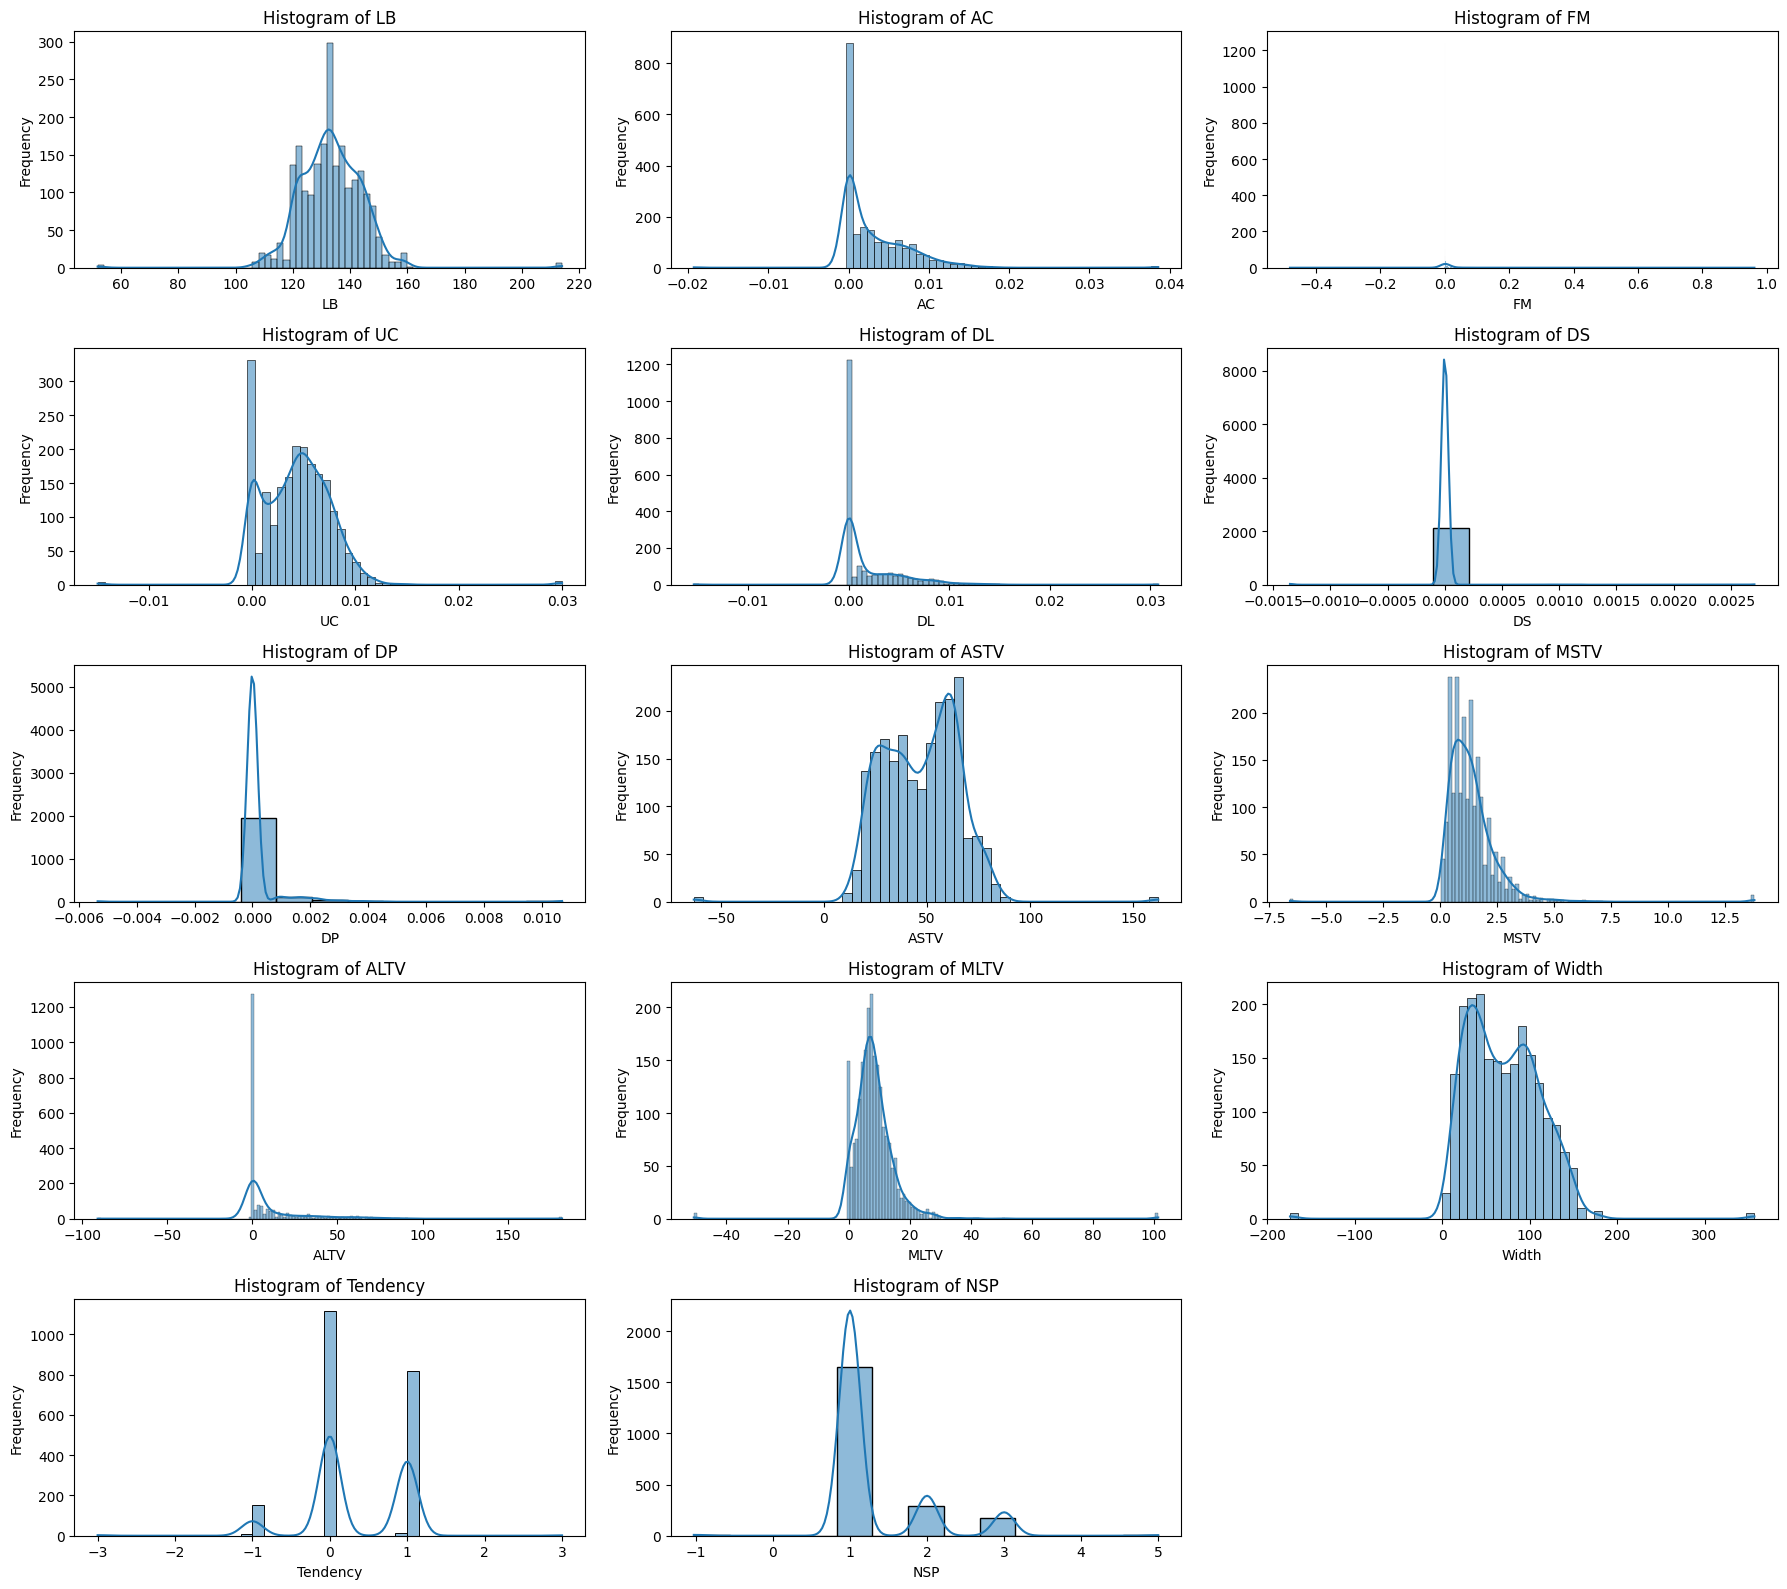

In [12]:
# Histograms for Numerical Columns

plt.figure(figsize=(18, 16))

for i, column in enumerate(df.select_dtypes(include=[np.number]).columns, 1):
    plt.subplot(5, 3, i)
    sns.histplot(df[column], kde=True)
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

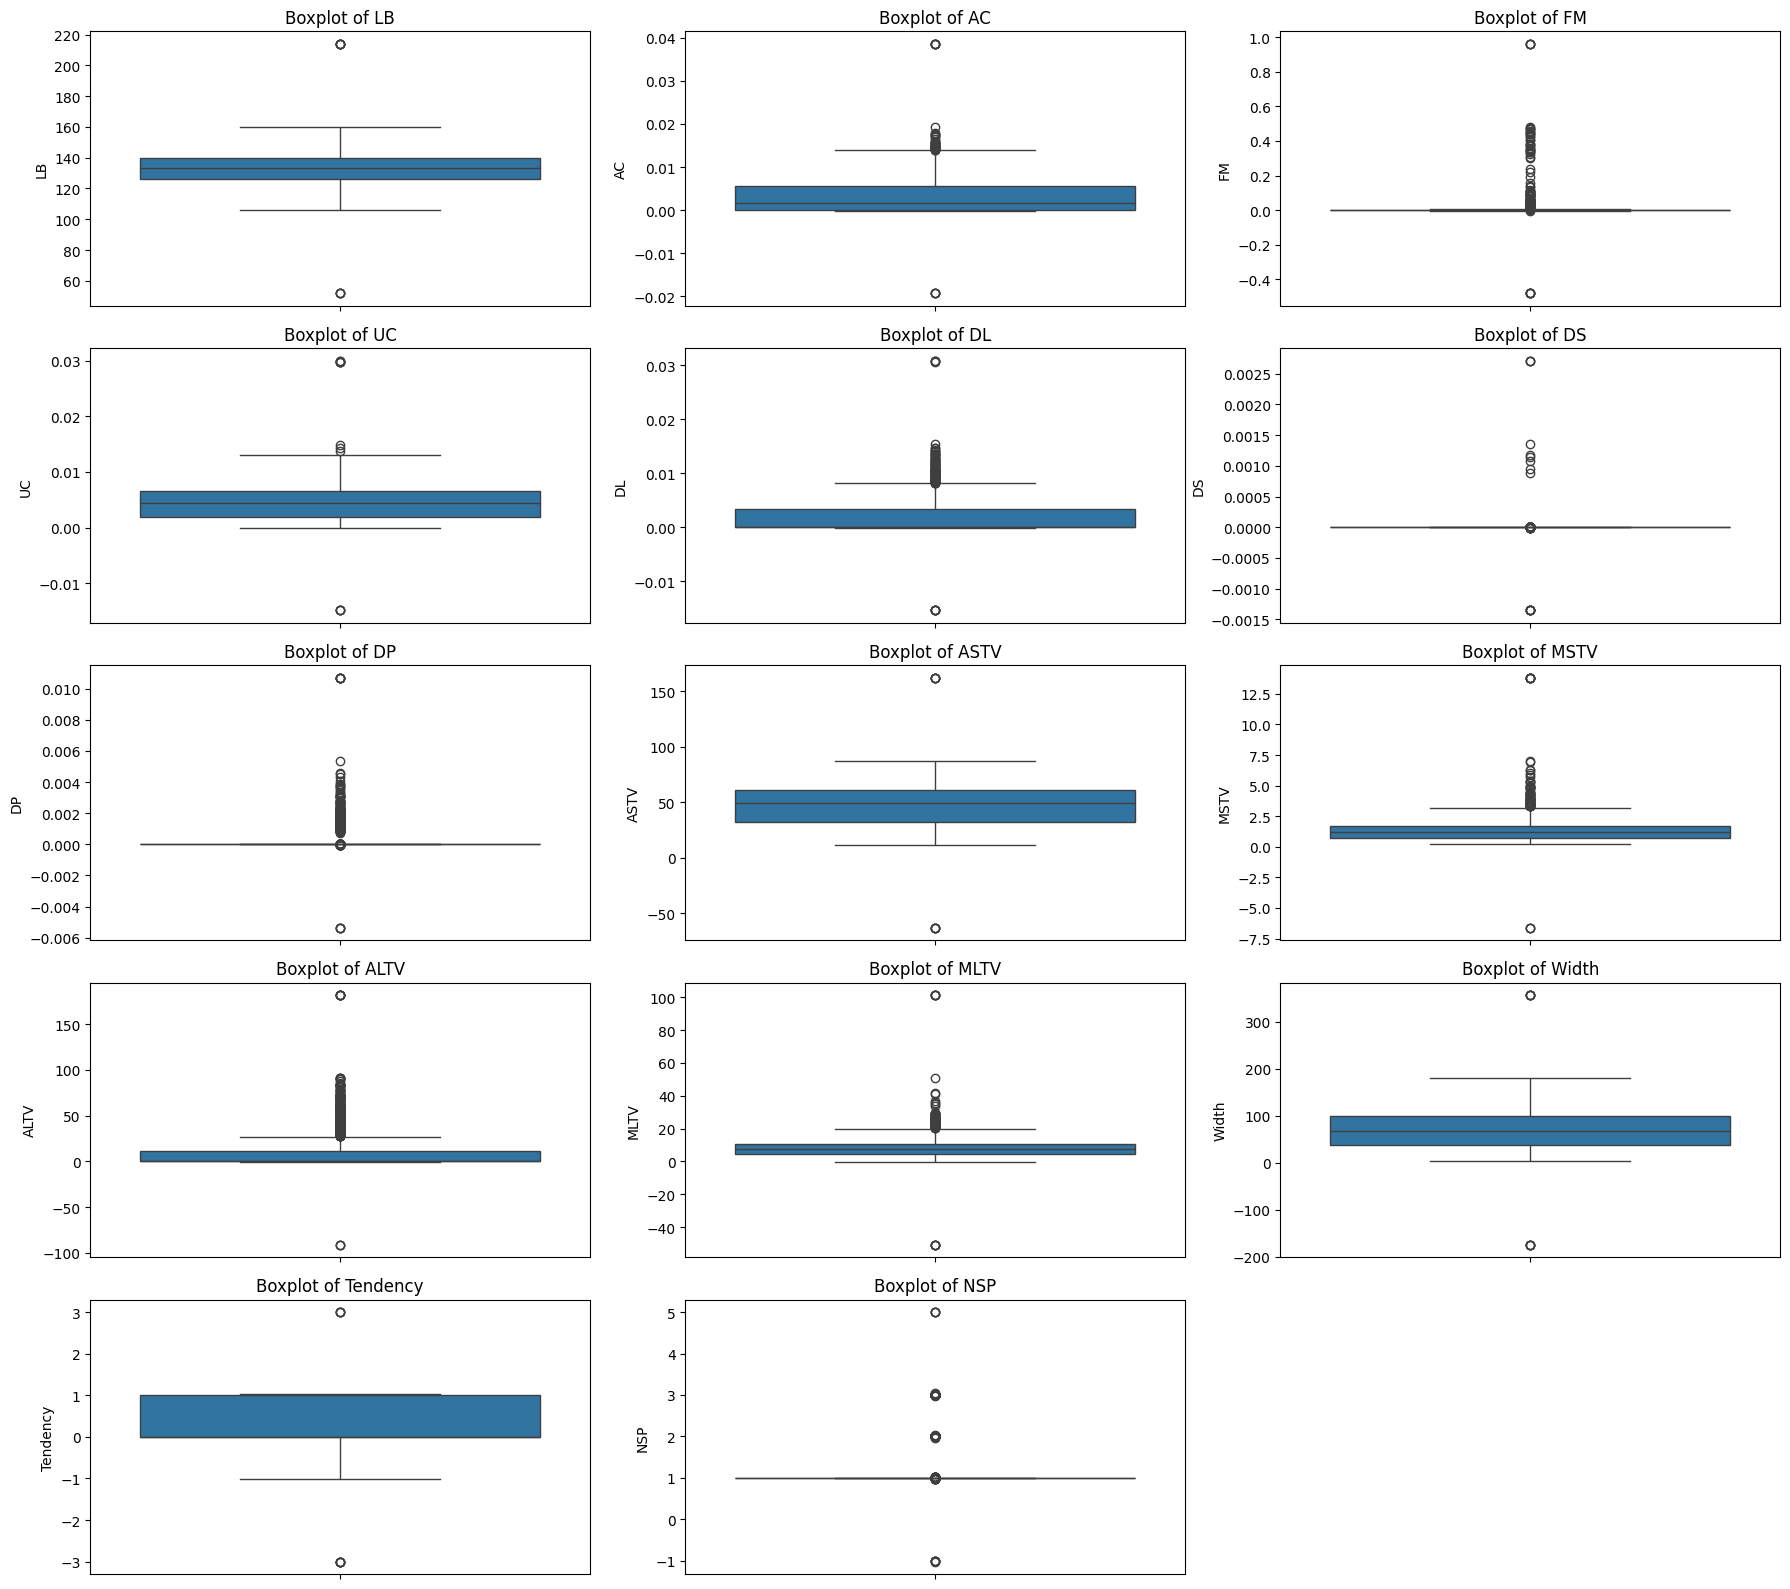

In [14]:
# Boxplots for Numerical Columns

plt.figure(figsize=(18, 16))

for i, column in enumerate(df.select_dtypes(include=[np.number]).columns, 1):
    plt.subplot(5, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

# Step 5A — Bar Charts + Pie Charts for Categorical Variables

In [15]:
# Create Categorical Variable from LB

def categorize_fhr(lb):
    if lb < 110:
        return "Low"
    elif lb <= 160:
        return "Normal"
    else:
        return "High"

df["FHR_Category"] = df["LB"].apply(categorize_fhr)

print("Frequency of FHR Categories:\n")
print(df["FHR_Category"].value_counts())

Frequency of FHR Categories:

FHR_Category
Normal    2108
Low         12
High         6
Name: count, dtype: int64


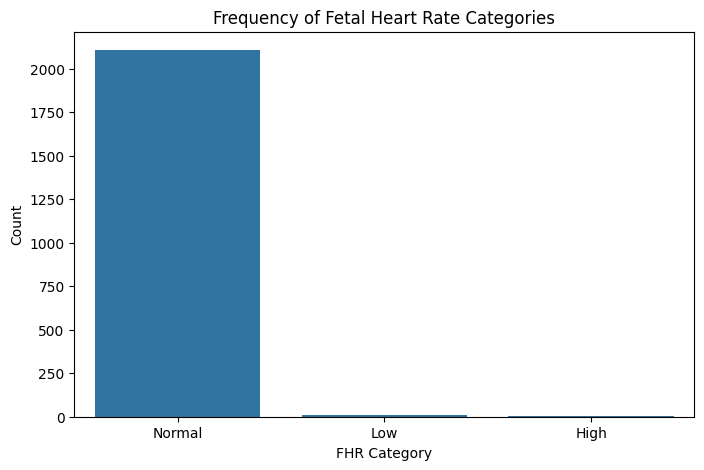

In [16]:
# Bar Chart for FHR Category

plt.figure(figsize=(8, 5))

sns.countplot(x="FHR_Category", data=df)

plt.title("Frequency of Fetal Heart Rate Categories")
plt.xlabel("FHR Category")
plt.ylabel("Count")

plt.show()

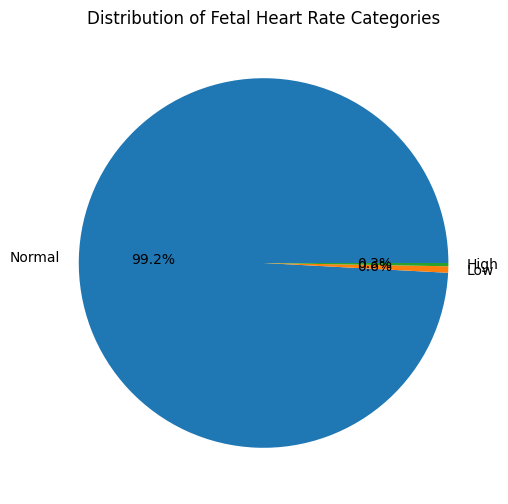

In [21]:
# Pie Chart for FHR Category

df["FHR_Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6, 6)
)

plt.title("Distribution of Fetal Heart Rate Categories")
plt.ylabel("")

plt.show()

# Step 6 — Correlation Heatmap + Scatter Plots

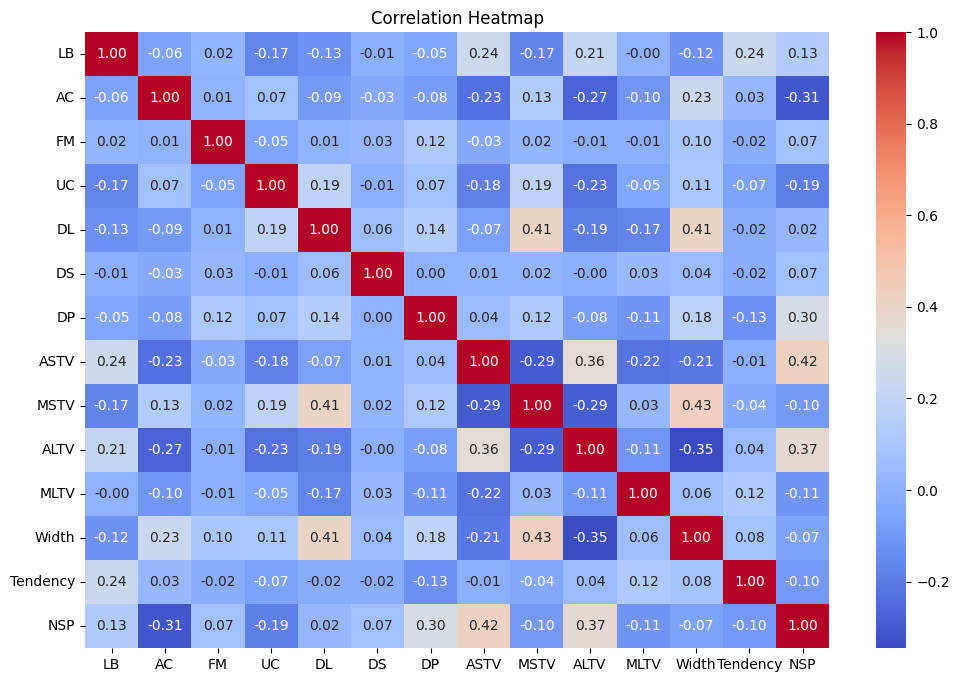

In [22]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

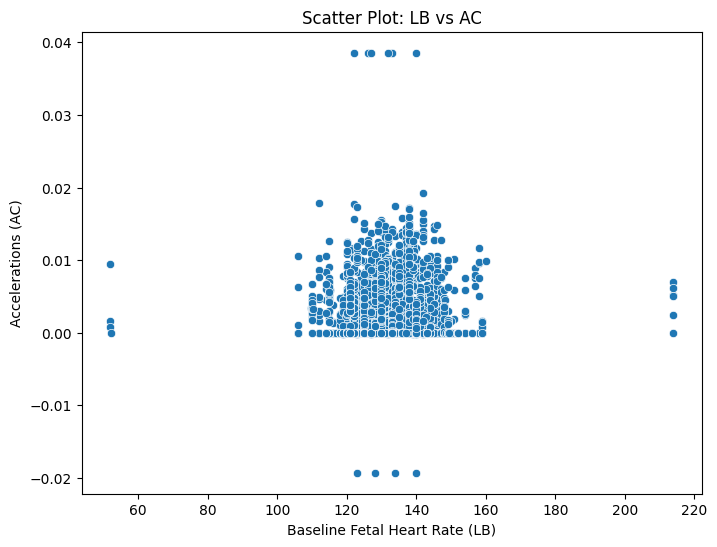

In [23]:
# Scatter Plot Example

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="LB",
    y="AC",
    data=df
)

plt.title("Scatter Plot: LB vs AC")
plt.xlabel("Baseline Fetal Heart Rate (LB)")
plt.ylabel("Accelerations (AC)")

plt.show()

# Step 7 — Pair Plot + Advanced Visualization (Pairplot + Violin Plot)

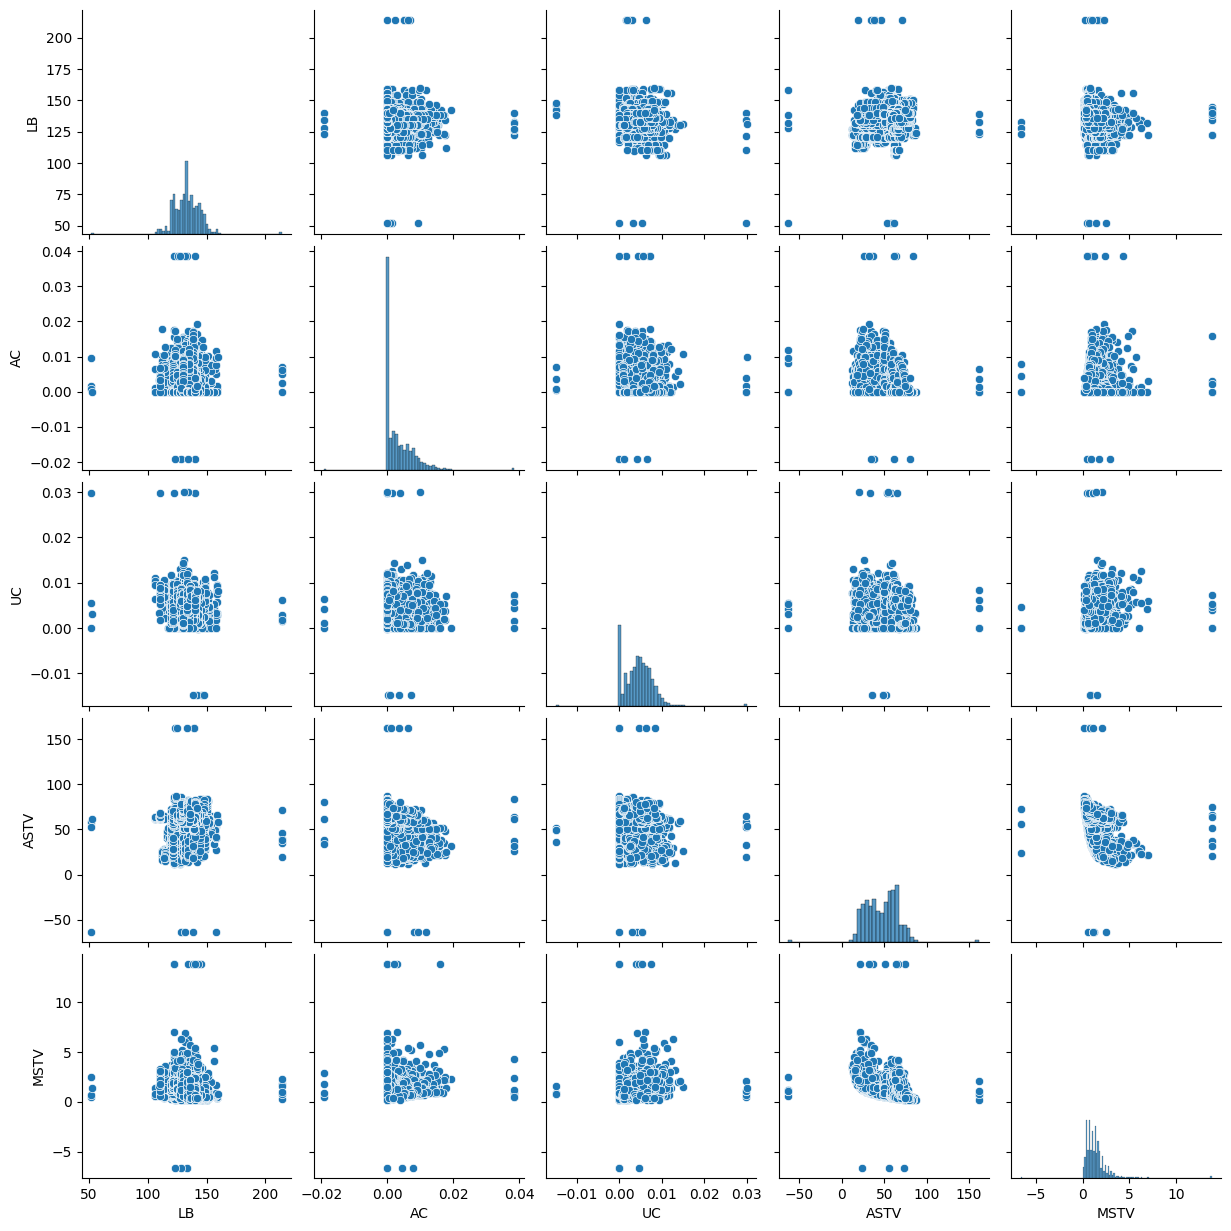

In [24]:
# Pair Plot

selected_columns = [
    "LB",
    "AC",
    "UC",
    "ASTV",
    "MSTV"
]

sns.pairplot(df[selected_columns])

plt.show()

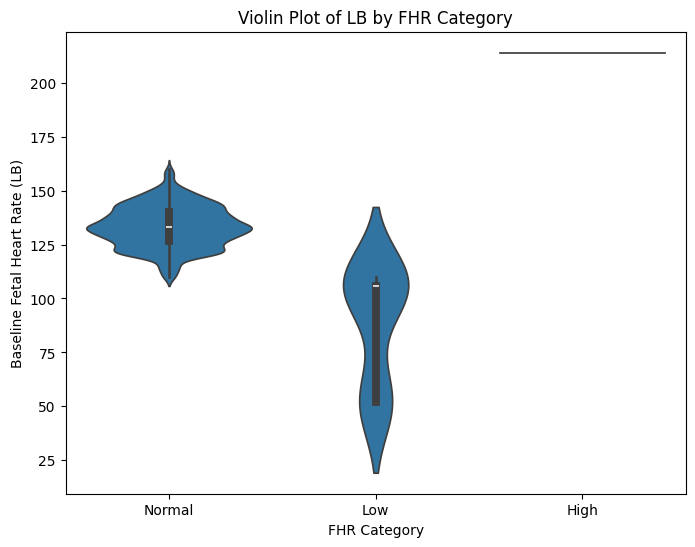

In [25]:
# Violin Plot

plt.figure(figsize=(8, 6))

sns.violinplot(
    x="FHR_Category",
    y="LB",
    data=df
)

plt.title("Violin Plot of LB by FHR Category")
plt.xlabel("FHR Category")
plt.ylabel("Baseline Fetal Heart Rate (LB)")

plt.show()

# Step 8 — Pattern Recognition + Key Insights

# Key Insights from EDA

1. Most medical variables show right-skewed distributions,
indicating that extreme values exist but most observations remain within normal ranges.

2. Baseline Fetal Heart Rate (LB) shows several upper outliers,
which may represent clinically significant fetal distress cases.

3. Strong positive relationships between uterine contractions (UC)
and decelerations suggest possible contraction-related fetal stress.

4. Variability measures like ASTV and ALTV show important relationships,
which may help identify abnormal fetal monitoring patterns.

5. Most fetal heart rate values fall into the Normal category,
indicating overall healthy fetal conditions for most observations.

# Step 9 — Final Conclusion + Professional Report Summary

# Final Conclusion

In this project, a complete Exploratory Data Analysis (EDA) was performed on the Cardiotocographic dataset to understand fetal heart monitoring patterns and identify meaningful medical insights.

The analysis began with loading and cleaning the dataset by handling missing values, checking data types, and preparing the data for reliable analysis. Missing numerical values were treated using median imputation, which is more robust for medical datasets with potential outliers.

Outlier detection was performed using the IQR method, helping identify extreme values that may represent either data errors or clinically important abnormal cases such as fetal distress. These outliers were carefully interpreted instead of being removed blindly.

Statistical summaries including mean, median, standard deviation, and interquartile range helped reveal the spread, skewness, and variability of important variables such as Baseline Fetal Heart Rate (LB), Uterine Contractions (UC), and variability measures like ASTV and ALTV.

Histograms and boxplots confirmed that several variables show right-skewed distributions and upper-side outliers, indicating that while most patients fall within normal ranges, a smaller number of cases may represent higher medical risk and require closer monitoring.

Categorical analysis was performed by creating FHR categories (Low, Normal, High) from Baseline Fetal Heart Rate values. Bar charts and pie charts showed that most observations fall within the Normal range, suggesting overall fetal well-being for the majority of patients.

Correlation heatmaps and scatter plots revealed meaningful relationships between variables, especially between uterine contractions and decelerations, which may indicate contraction-related fetal stress. Relationships between short-term and long-term variability measures also provided important insights for identifying abnormal fetal monitoring patterns.

Advanced visualizations such as pair plots and violin plots provided deeper understanding of data distributions, group behavior, and patient variability patterns, making the analysis more comprehensive and clinically meaningful.

Overall, this project demonstrates that effective EDA is not just about creating charts, but about converting data into actionable medical insights that support better monitoring, risk identification, and healthcare decision-making.

These findings can support doctors in early detection of fetal distress, prioritization of high-risk pregnancies, and improved pregnancy monitoring systems. The cleaned and analyzed dataset is also ready for further advanced analytics such as classification modeling, predictive healthcare systems, and medical decision support tools.

Thus, this project reflects strong real-world Data Analyst skills where data cleaning, visualization, interpretation, and domain understanding work together to create reliable business and healthcare intelligence.